In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arcpy
from arcpy.ia import *
from arcpy import AIO

In [2]:
# Bounding box dla zbiornika Asprokremmos
bbox = [32.53, 34.724685, 32.578648, 34.762221] 

# zakres dat 
date_range = "2025-06-06T00:00:00Z/2026-06-01T23:59:59Z"

# Poprawione zakresy dla zapytań STAC
date_range_old = "2025-06-01T00:00:00Z/2025-06-09T23:59:59Z"
date_range_new = "2026-06-01T00:00:00Z/2026-06-08T23:59:59Z"

# maksymalne pokrycie chmur
max_cloud_cover = 5

In [3]:
# starsza scena (np. lato 2025)
query_old = {
    "collections": ["sentinel-2-l2a"],
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": date_range_old, #tylko to zmieniamy
    "limit": 1  # 1 najlepsze zdjęcie
}

# nowa scena (np. lato 2026)
query_new = {
    "collections": ["sentinel-2-l2a"],
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": date_range_new, #tylko to zmieniamy
    "limit": 1  # 1 najlepsze zdjęcie
}

# zdefiniowanie pasm: 1=Red, 2=Green, 3=Blue, 4=NIR
selected_bands = ["B4", "B3", "B2", "B8"]

# pobieranie kolekcji z niepełnym zestawem pasm
rc_old = arcpy.ia.RasterCollection.fromSTACAPI("https://earth-search.aws.element84.com/v1", 
                                               query=query_old, 
                                               attribute_dict={"Name":"id", 
                                                               "StdTime":"datetime"}).selectBands(selected_bands)
rc_new = arcpy.ia.RasterCollection.fromSTACAPI("https://earth-search.aws.element84.com/v1", 
                                               query=query_new, 
                                               attribute_dict={"Name":"id", 
                                                               "StdTime":"datetime"}).selectBands(selected_bands)


In [4]:
raster_old = rc_old[0]["Raster"]
raster_new = rc_new[0]["Raster"]

In [5]:
# Układ źródłowy (WGS84) i docelowy (układ rastra)
sr_wgs84 = arcpy.SpatialReference(4326)
sr_raster = raster_old.spatialReference  # np. UTM 36N

# Punkt dolny-lewy i górny-prawy w WGS84
pt_min = arcpy.Point(bbox[0], bbox[1])
pt_max = arcpy.Point(bbox[2], bbox[3])

# Transformacja do układu rastra
pt_min_proj = arcpy.PointGeometry(pt_min, sr_wgs84).projectAs(sr_raster)
pt_max_proj = arcpy.PointGeometry(pt_max, sr_wgs84).projectAs(sr_raster)

# Nowy extent w układzie rastra
extent_proj = arcpy.Extent(
    pt_min_proj.firstPoint.X,
    pt_min_proj.firstPoint.Y,
    pt_max_proj.firstPoint.X,
    pt_max_proj.firstPoint.Y,
    spatial_reference=sr_raster
)

print("Extent po transformacji:", extent_proj)

Extent po transformacji: 456968,395797226 3842612,90948675 461439,917002219 3846755,63702541 NaN NaN NaN NaN


In [6]:
from arcpy.ia import Clip as iaClip

clipped_old = iaClip(raster_old, extent_proj)
clipped_new = iaClip(raster_new, extent_proj)

arr_old_full = arcpy.RasterToNumPyArray(raster_old, nodata_to_value=0)
arr_new_full = arcpy.RasterToNumPyArray(raster_new, nodata_to_value=0)

arr_old = arcpy.RasterToNumPyArray(clipped_old, nodata_to_value=0)
arr_new = arcpy.RasterToNumPyArray(clipped_new, nodata_to_value=0)

In [7]:
print("Rozmiar arr_old:", arr_old_full.shape)
print("Rozmiar arr_new:", arr_new_full.shape)

print("Rozmiar arr_old:", arr_old.shape)
print("Rozmiar arr_new:", arr_new.shape)

Rozmiar arr_old: (4, 10980, 10980)
Rozmiar arr_new: (4, 10980, 10980)
Rozmiar arr_old: (4, 415, 448)
Rozmiar arr_new: (4, 415, 448)


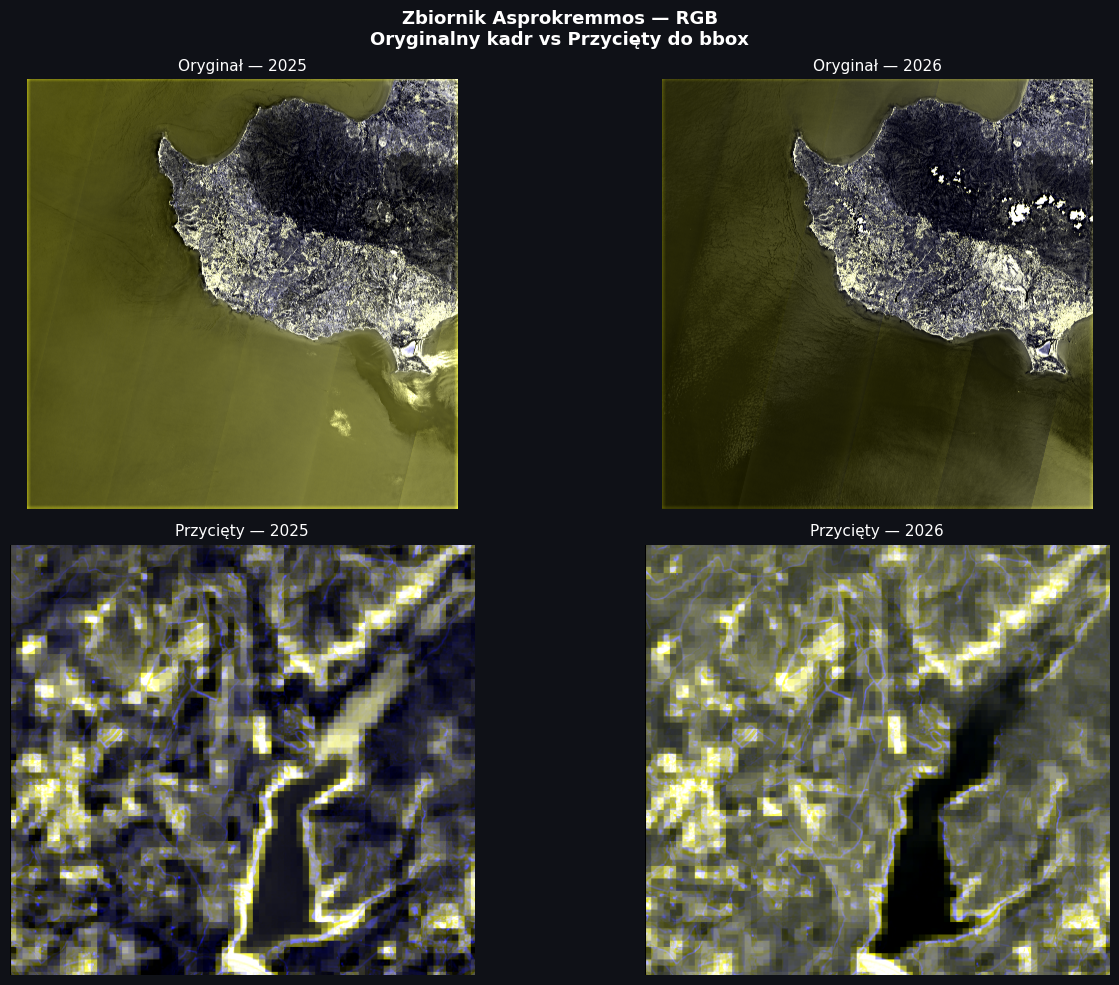

Oryginał 2025:  (4, 10980, 10980)  →  (10980, 10980) px
Oryginał 2026:  (4, 10980, 10980)  →  (10980, 10980) px
Przycięty 2025: (4, 415, 448)        →  (415, 448) px
Przycięty 2026: (4, 415, 448)        →  (415, 448) px


In [8]:
# def to_rgb(arr, clip_max=3000):
#     # Wybieramy indeksy: 2 (Red), 1 (Green), 0 (Blue)
#     # NIR (indeks 3) zostaje całkowicie pominięty!
#     rgb = arr[[1, 2, 0], :, :] 

#     # 210 = green
#     # 201 = blue
#     # 102 = czerwony
#     # 012 = green
#     # 021 = blue
#     # 120 = czerwony 
    
#     # Transpozycja
#     rgb = np.transpose(rgb, (1, 2, 0))
    
#     # Normalizacja
#     rgb = np.clip(rgb, 0, clip_max) / clip_max
#     return rgb

def to_rgb(arr):
    """
    Konwersja z automatyczną normalizacją (min-max dla każdego kanału).
    """
    rgb = arr[[0, 1, 2], :, :].astype(np.float32)
    
    # 2. Normalizacja każdego kanału osobno do zakresu [0, 1]
    for i in range(3):
        ch = rgb[i, :, :]
        # Używamy percentyli, aby odrzucić szum (np. 2% i 98%)
        p2, p98 = np.percentile(ch, (2, 98))
        rgb[i, :, :] = np.clip((ch - p2) / (p98 - p2), 0, 1)
        
    return np.transpose(rgb, (1, 2, 0))

rgb_old_full = to_rgb(arr_old_full)
rgb_new_full = to_rgb(arr_new_full)
rgb_old      = to_rgb(arr_old)
rgb_new      = to_rgb(arr_new)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="#0f1117")
fig.suptitle(
    "Zbiornik Asprokremmos — RGB\nOryginalny kadr vs Przycięty do bbox",
    color="white", fontsize=13, fontweight="bold"
)

panels = [
    (axes[0, 0], rgb_old_full, "Oryginał — 2025"),
    (axes[0, 1], rgb_new_full, "Oryginał — 2026"),
    (axes[1, 0], rgb_old,      "Przycięty — 2025"),
    (axes[1, 1], rgb_new,      "Przycięty — 2026"),
]

for ax, img, title in panels:
    ax.imshow(img, interpolation="bilinear")
    ax.set_title(title, color="white", fontsize=11, pad=6)
    ax.axis("off")
    ax.set_facecolor("#0f1117")

for ax, label in [(axes[0, 0], "ORYGINAŁ"), (axes[1, 0], "PRZYCIĘTY")]:
    ax.set_ylabel(label, color="#aaaaaa", fontsize=10,
                  rotation=90, labelpad=8, va="center")
    ax.yaxis.set_label_position("left")

plt.tight_layout()
plt.show()

# Kontrola rozmiarów
print(f"Oryginał 2025:  {arr_old_full.shape}  →  {rgb_old_full.shape[:2]} px")
print(f"Oryginał 2026:  {arr_new_full.shape}  →  {rgb_new_full.shape[:2]} px")
print(f"Przycięty 2025: {arr_old.shape}        →  {rgb_old.shape[:2]} px")
print(f"Przycięty 2026: {arr_new.shape}        →  {rgb_new.shape[:2]} px")

In [9]:
def adjust_rgb(arr):
    ref = arr * 0.0000275 - 0.2
    ref = np.clip(ref, 0, None)
    vmax = 0.3  
    return np.clip(ref / vmax, 0, 1)

s_r_old = adjust_rgb(arr_old[[0],:,:])
s_g_old = adjust_rgb(arr_old[[1],:,:])
s_b_old = adjust_rgb(arr_old[[2],:,:])

s_r_new = adjust_rgb(arr_new[[0],:,:])
s_g_new = adjust_rgb(arr_new[[1],:,:])
s_b_new = adjust_rgb(arr_new[[2],:,:])

# rgb_old = np.stack([s_r_old, s_g_old, s_b_old], axis=-1)
# rgb_new = np.stack([s_r_new, s_g_new, s_b_new], axis=-1)

# rgb_old = rgb_old.squeeze()
# rgb_new = rgb_new.squeeze()

In [10]:
# konwersja na float, aby zapobiec błędom dzielenia i przepełnienia typów
g_old_f = arr_old[[1],:,:].astype(float)
g_new_f = arr_new[[1],:,:].astype(float)

nir_old_f = arr_old[[3],:,:].astype(float)
nir_new_f = arr_new[[3],:,:].astype(float)

denom_old = g_old_f + nir_old_f
denom_new = g_new_f + nir_new_f

# bezpieczne dzielenie (tam gdzie mianownik to 0, wpisujemy 0)
ndwi_old = np.where(denom_old == 0, 0, (g_old_f - nir_old_f) / denom_old)
ndwi_new = np.where(denom_new == 0, 0, (g_new_f - nir_new_f) / denom_new)

C:\Users\znozk\AppData\Local\Temp\ipykernel_11868\3483635983.py:12: RuntimeWarning: invalid value encountered in divide
  ndwi_old = np.where(denom_old == 0, 0, (g_old_f - nir_old_f) / denom_old)
C:\Users\znozk\AppData\Local\Temp\ipykernel_11868\3483635983.py:13: RuntimeWarning: invalid value encountered in divide
  ndwi_new = np.where(denom_new == 0, 0, (g_new_f - nir_new_f) / denom_new)


In [11]:
# maska prawidłowych danych (wykluczamy czarne rogi rombu)
valid_data_old = denom_old > 0
valid_data_new = denom_new > 0

# generowanie binarnej maski (True dla śniegu/lodu, False dla reszty)
snow_mask_old = ndwi_old > 0.0
snow_mask_new = ndwi_new > 0.0

snow_mask_old = np.squeeze(snow_mask_old)
snow_mask_new = np.squeeze(snow_mask_new)

snow_pixels_old = np.sum(snow_mask_old & valid_data_old)
total_pixels_old = np.sum(valid_data_old)
pct_snow_old = (snow_pixels_old / total_pixels_old) * 100 if total_pixels_old > 0 else 0

snow_pixels_new = np.sum(snow_mask_new & valid_data_new)
total_pixels_new = np.sum(valid_data_new)
pct_snow_new = (snow_pixels_new / total_pixels_new) * 100 if total_pixels_new > 0 else 0

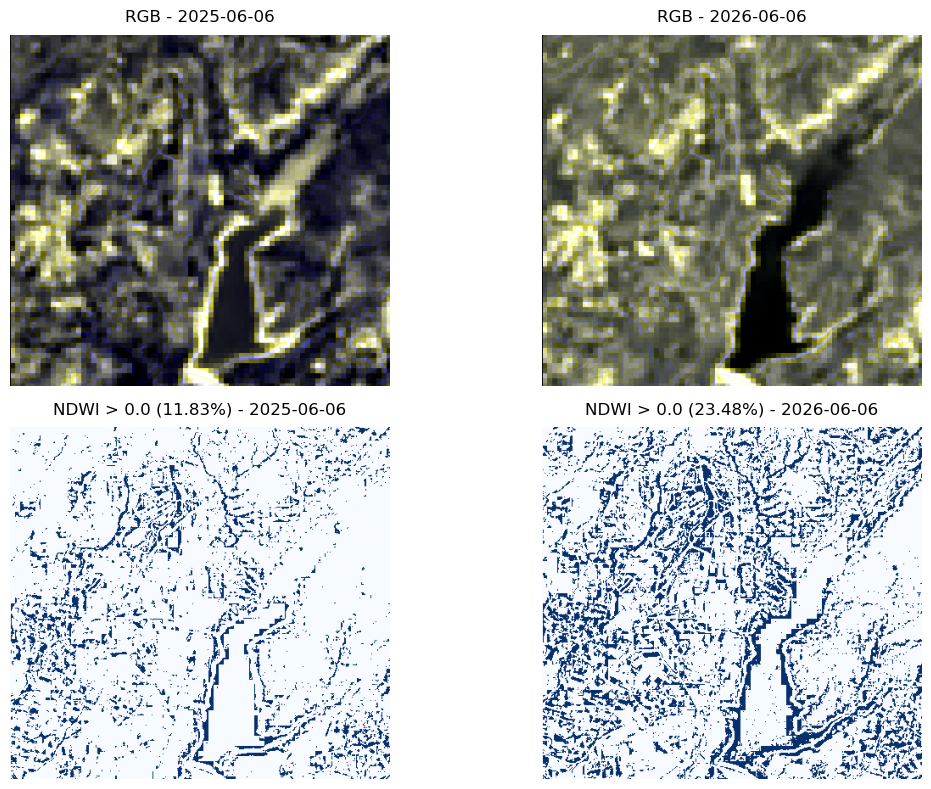

In [12]:
date_old = str(rc_old[0]["StdTime"])[:10]
date_new = str(rc_new[0]["StdTime"])[:10]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# pierwszy wiersz - RGB
axes[0, 0].imshow(rgb_old)
axes[0, 0].set_title(f"RGB - {date_old}", pad=10)
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_new)
axes[0, 1].set_title(f"RGB - {date_new}", pad=10)
axes[0, 1].axis('off')

axes[1, 0].imshow(snow_mask_old, cmap='Blues')
axes[1, 0].set_title(f"NDWI > 0.0 ({pct_snow_old:.2f}%) - {date_old}", pad=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(snow_mask_new, cmap='Blues')
axes[1, 1].set_title(f"NDWI > 0.0 ({pct_snow_new:.2f}%) - {date_new}", pad=10)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

C:\Users\znozk\AppData\Local\Temp\ipykernel_11868\3259961697.py:25: RuntimeWarning: invalid value encountered in divide
  ndwi_old = np.where(denom_old == 0, 0, (green_old - nir_old) / denom_old)
C:\Users\znozk\AppData\Local\Temp\ipykernel_11868\3259961697.py:26: RuntimeWarning: invalid value encountered in divide
  ndwi_new = np.where(denom_new == 0, 0, (green_new - nir_new) / denom_new)


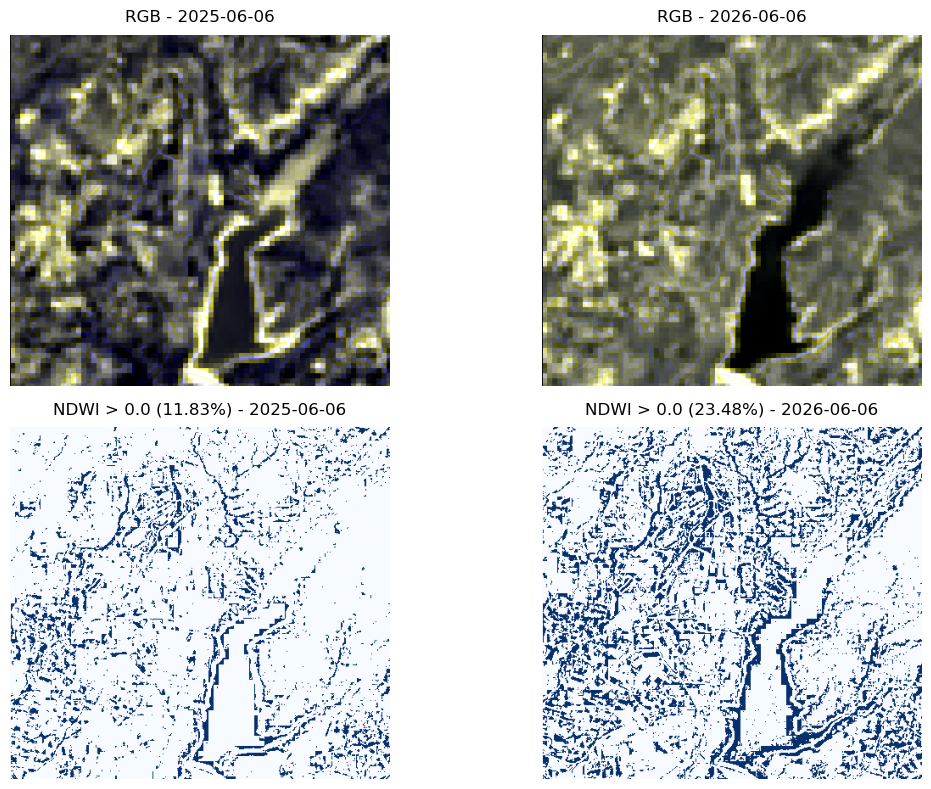

In [13]:
red_old   = arr_old[0, :, :].astype(float) / 10000.0
green_old = arr_old[1, :, :].astype(float) / 10000.0
blue_old  = arr_old[2, :, :].astype(float) / 10000.0
nir_old   = arr_old[3, :, :].astype(float) / 10000.0

red_new   = arr_new[0, :, :].astype(float) / 10000.0
green_new = arr_new[1, :, :].astype(float) / 10000.0
blue_new  = arr_new[2, :, :].astype(float) / 10000.0
nir_new   = arr_new[3, :, :].astype(float) / 10000.0

# %%
# 1. PRZYGOTOWANIE RGB
# Łączymy pasma R, G, B w jeden obraz i przycinamy do zakresu [0, 1]
# Opcjonalnie: mnożymy przez powiększenie (np. 2.5), aby rozjaśnić obraz
# vmax = 0.3  # maksymalny oczekiwany refleks dla wizualizacji (zapobiega prześwietleniu)
# rgb_old = np.clip(np.stack([red_old, green_old, blue_old], axis=-1) / vmax, 0, 1)
# rgb_new = np.clip(np.stack([red_new, green_new, blue_new], axis=-1) / vmax, 0, 1)


# %%
# 2. OBLICZENIE WSKAŹNIKA NDWI (dla wody: (Green - NIR) / (Green + NIR))
denom_old = green_old + nir_old
denom_new = green_new + nir_new

ndwi_old = np.where(denom_old == 0, 0, (green_old - nir_old) / denom_old)
ndwi_new = np.where(denom_new == 0, 0, (green_new - nir_new) / denom_new)


# %%
# 3. MASKOWANIE WODY (Zbiornik Asprokremmos)
# Dla czystej wody NDWI jest zazwyczaj dodatnie (> 0 lub > 0.1)
# Jeśli celowo szukasz śniegu za pomocą NDSI, formuła to (Green - SWIR) / (Green + SWIR), 
# ale nie pobrałeś pasma SWIR (B11) w selected_bands. Zakładam, że badasz wodę (NDWI).

water_threshold = 0.0  # Próg dla wody, możesz dostosować (np. 0.0 lub 0.2)

valid_data_old = denom_old > 0
valid_data_new = denom_new > 0

water_mask_old = ndwi_old > water_threshold
water_mask_new = ndwi_new > water_threshold

# Obliczenie procentu powierzchni wody
water_pixels_old = np.sum(water_mask_old & valid_data_old)
total_pixels_old = np.sum(valid_data_old)
pct_water_old = (water_pixels_old / total_pixels_old) * 100 if total_pixels_old > 0 else 0

water_pixels_new = np.sum(water_mask_new & valid_data_new)
total_pixels_new = np.sum(valid_data_new)
pct_water_new = (water_pixels_new / total_pixels_new) * 100 if total_pixels_new > 0 else 0


# %%
# 4. RYSOWANIE WYKRESÓW
date_old = str(rc_old[0]["StdTime"])[:10]
date_new = str(rc_new[0]["StdTime"])[:10]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Pierwszy wiersz - RGB
axes[0, 0].imshow(rgb_old)
axes[0, 0].set_title(f"RGB - {date_old}", pad=10)
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_new)
axes[0, 1].set_title(f"RGB - {date_new}", pad=10)
axes[0, 1].axis('off')

# Drugi wiersz - NDWI (Maska wody)
axes[1, 0].imshow(water_mask_old, cmap='Blues')
axes[1, 0].set_title(f"NDWI > {water_threshold} ({pct_water_old:.2f}%) - {date_old}", pad=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(water_mask_new, cmap='Blues')
axes[1, 1].set_title(f"NDWI > {water_threshold} ({pct_water_new:.2f}%) - {date_new}", pad=10)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()